In [16]:
import json
import math
import pickle
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

### Load Data

In [ ]:
data_dir  = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')

# Processed BIO sequences
with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

# Vocabularies
with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    Entity_labels = v['Entity_labels']
    label2id      = v['label2id']
    id2label      = v['id2label']

# Train / val / test split indices (shared across all models)
with open(split_dir / 'split_indices.json') as f:
    split     = json.load(f)
idx_train = split['idx_train']
idx_val   = split['idx_val']
idx_test  = split['idx_test']

# CRF/HMM splits — sudah dibagi di Preprocessing.ipynb (no leakage)
with open(data_dir / 'crf_train.pkl', 'rb') as f:
    crf_train = pickle.load(f)   # list of (features, labels)
with open(data_dir / 'crf_val.pkl', 'rb') as f:
    crf_val   = pickle.load(f)
with open(data_dir / 'crf_test.pkl', 'rb') as f:
    crf_test  = pickle.load(f)

print(f"Resumes loaded : {len(processed)}")
print(f"Entity labels  : {Entity_labels}")
print(f"Train / Val / Test : {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")
print(f"CRF splits     : train={len(crf_train)} / val={len(crf_val)} / test={len(crf_test)}") # hasil imbalance handling

Resumes loaded : 220
Entity labels  : ['Name', 'Designation', 'Companies worked at', 'Location', 'Email Address', 'College Name', 'Degree', 'Graduation Year', 'Skills', 'Years of Experience']
Train / Val / Test : 154 / 33 / 33
CRF splits     : train=300 / val=33 / test=33


### BIO Sequence Extraction

In [18]:
# Extract token & tag sequences langsung dari crf splits (sudah benar splitnya)

def extract_sequences(crf_split):
    """Return (token_sequences, tag_sequences) dari crf split."""
    tokens_list = [[feat['token'] for feat in feats] for feats, _ in crf_split]
    tags_list   = [labels for _, labels in crf_split]
    return tokens_list, tags_list

train_tokens, train_tags = extract_sequences(crf_train)
val_tokens,   val_tags   = extract_sequences(crf_val)
test_tokens,  test_tags  = extract_sequences(crf_test)

# Gabung train+val untuk final model (setelah hyperparameter tuning)
all_train_tokens = train_tokens + val_tokens
all_train_tags   = train_tags   + val_tags

from collections import Counter
all_tags_flat = [t for seq in all_train_tags for t in seq]
tc    = Counter(all_tags_flat)
total = sum(tc.values())
print(f"Total tokens (train+val) : {total:,}")
print(f"'O' tokens               : {tc['O']:,}  ({100*tc['O']/total:.1f}%)")
print(f"Entity tokens            : {total - tc['O']:,}  ({100*(total-tc['O'])/total:.1f}%)")

Total tokens (train+val) : 149,236
'O' tokens               : 131,664  (88.2%)
Entity tokens            : 17,572  (11.8%)


### Word Similarity Feature

In [19]:
def char_trigrams(word: str) -> set:
    """Return the set of character trigrams for a word."""
    w = f"  {word}  "   # boundary padding
    return {w[i:i+3] for i in range(len(w) - 2)}


def trigram_similarity(w1: str, w2: str) -> float:
    """Jaccard similarity between the trigram sets of two words."""
    t1, t2 = char_trigrams(w1), char_trigrams(w2)
    inter = len(t1 & t2)
    union = len(t1 | t2)
    return inter / union if union else 0.0


def build_similarity_index(
    vocab: list[str],
    top_k: int = 10,
    min_sim: float = 0.2
) -> dict[str, list[tuple[str, float]]]:
    """
    For every word in vocab, precompute the top-k most similar words
    (by trigram Jaccard) with similarity >= min_sim.

    Returns
    -------
    sim_index : dict  word -> [(similar_word, similarity), ...]
    """
    sim_index = {}
    vocab_list = list(vocab)
    n = len(vocab_list)
    for i, w1 in enumerate(vocab_list):
        sims = []
        for j, w2 in enumerate(vocab_list):
            if i == j:
                continue
            s = trigram_similarity(w1, w2)
            if s >= min_sim:
                sims.append((w2, s))
        sims.sort(key=lambda x: -x[1])
        sim_index[w1] = sims[:top_k]
    return sim_index


# Build vocabulary from training tokens
train_vocab = sorted({tok for seq in all_train_tokens for tok in seq})
print(f"Training vocabulary size: {len(train_vocab):,}")
print("Building similarity index (may take ~30 s for large vocab) ...")

sim_index = build_similarity_index(train_vocab, top_k=10, min_sim=0.2)
print("Done.")

# Quick demo
demo_word = "engineer"
print(f"\nTop similar words to '{demo_word}':")
for w, s in sim_index.get(demo_word, [])[:5]:
    print(f"  {w:<25}  sim={s:.3f}")

Training vocabulary size: 7,157
Building similarity index (may take ~30 s for large vocab) ...
Done.

Top similar words to 'engineer':
  engineers                  sim=0.615
  enginner                   sim=0.538
  engineering                sim=0.533
  engine                     sim=0.500
  enginerre                  sim=0.400


### Parameter Estimation

In [20]:
class HiddenMarkovModel:
    """
    First-order HMM for BIO-tag sequence labelling.

    Parameters
    ----------
    alpha : float
        Laplace smoothing for transition & emission counts.
    lam : float
        Similarity-smoothing mixture weight (0 = no smoothing, 1 = full).
    sim_index : dict
        Precomputed word-similarity index  word -> [(sim_word, score), ...].
    """

    def __init__(
        self,
        alpha: float = 0.05,
        lam:   float = 0.1,
        sim_index: dict | None = None,
    ):
        self.alpha = alpha
        self.lam = lam
        self.sim_index = sim_index or {}

        # Will be filled during fit()
        self.tags_: list[str] = []
        self.vocab_: set[str] = set()
        self.tag2id_: dict[str, int] = {}
        self.id2tag_: dict[int, str] = {}

        # Raw count tables
        self._trans_counts: dict = defaultdict(lambda: defaultdict(int))
        self._emit_counts: dict = defaultdict(lambda: defaultdict(int))
        self._tag_counts: dict = defaultdict(int)
        self._init_counts: dict = defaultdict(int)
        self._trans_from_counts = defaultdict(int)

        # Log-probability tables (filled by _finalize)
        self.log_trans_: np.ndarray | None = None   # (n_tags, n_tags)
        self.log_init_: np.ndarray | None = None   # (n_tags,)

    # Fitting

    def fit(self, token_seqs: list[list[str]], tag_seqs: list[list[str]]):
        """Estimate HMM parameters from labelled token/tag sequences."""
        assert len(token_seqs) == len(tag_seqs)

        # Collect tag / vocab universe
        for tags in tag_seqs:
            for t in tags:
                self._tag_counts[t] += 0   # just register
        self.tags_ = sorted(self._tag_counts.keys())
        self.tag2id_ = {t: i for i, t in enumerate(self.tags_)}
        self.id2tag_ = {i: t for t, i in self.tag2id_.items()}

        # Count transitions, emissions, initial tags
        for tokens, tags in zip(token_seqs, tag_seqs):
            self._init_counts[tags[0]] += 1
            for i, (tok, tag) in enumerate(zip(tokens, tags)):
                self._tag_counts[tag] += 1
                self._emit_counts[tag][tok] += 1
                self.vocab_.add(tok)
                if i > 0:
                    self._trans_counts[tags[i - 1]][tag] += 1
                    self._trans_from_counts[tags[i - 1]] += 1

        self._finalize()
        return self
    
    # BIO Validity Check

    @staticmethod
    def _valid_bio(t_from: str, t_to: str) -> bool:
        """
        Return False for structurally impossible BIO transitions:
          - O  -> I-X  (impossible: I must follow B or I of same entity)
          - B-X -> I-Y (entity mismatch)
          - I-X -> I-Y (entity mismatch)
        """
        if t_to.startswith('I-'):
            entity_to = t_to[2:]
            if t_from.startswith('B-') or t_from.startswith('I-'):
                return t_from[2:] == entity_to
            return False   # O -> I-X
        return True
    
    # Paramter Finalization

    def _finalize(self):
        """Convert counts to smoothed log-probability matrices."""
        n = len(self.tags_)
        a = self.alpha

        # Initial log-probs
        total_init = sum(self._init_counts.values())
        self.log_init_ = np.array([
            math.log((self._init_counts[t] + a) / (total_init + a * n))
            for t in self.tags_
        ])

        # Transition log-probs (n x n matrix)
        log_trans = np.full((n, n), -np.inf)
        for i, t_from in enumerate(self.tags_):
            cnt_from = self._trans_from_counts[t_from]
            for j, t_to in enumerate(self.tags_):
                if not self._valid_bio(t_from, t_to):
                    log_trans[i, j] = -1e9
                    continue
                cnt = self._trans_counts[t_from][t_to]
                log_trans[i, j] = math.log((cnt + a) / (cnt_from + a * n))
        self.log_trans_ = log_trans

    # Emission (with similarity smoothing, computed on-the-fly)
    def _log_emit(self, word: str, tag: str) -> float:
        """
        Smoothed log-emission probability for (word, tag).

        For in-vocabulary words:
            P_smooth = (1-lam)*P_ML + lam * similarity-weighted mixture

        For OOV words:
            P_smooth = lam * similarity-weighted mixture  (no ML term)
            Falls back to uniform if no similar in-vocab words found.
        """
        a = self.alpha
        tag_cnt = self._tag_counts[tag]
        vocab_sz = len(self.vocab_)

        # Maximum-likelihood emission (Laplace smoothed)
        emit_cnt = self._emit_counts[tag][word]
        p_ml = (emit_cnt + a) / (tag_cnt + a * vocab_sz)

        # Similarity-smoothed component
        sim_nb = self.sim_index.get(word, [])
        if sim_nb and self.lam > 0:
            sim_sum = sum(s for _, s in sim_nb)
            p_sim = sum(
                (s / sim_sum) * ((self._emit_counts[tag][nw] + a) / (tag_cnt + a * vocab_sz)) for nw, s in sim_nb)
            p_smooth = (1.0 - self.lam) * p_ml + self.lam * p_sim
        else:
            p_smooth = p_ml

        return math.log(max(p_smooth, 1e-300))

    # Viterbi Decoding

    def predict_single(self, tokens: list[str]) -> list[str]:
        """
        Viterbi decoding for one token sequence.

        Returns the most-likely BIO tag sequence.
        """
        n_tags = len(self.tags_)
        T = len(tokens)
        if T == 0:
            return []
        # viterbi[t][j] = max log-prob of any path ending in tag j at position t
        # backptr[t][j] = argmax tag at position t-1
        viterbi = np.full((T, n_tags), -np.inf)
        backptr = np.zeros((T, n_tags), dtype=int)

        # Initialisation (t=0) 
        for j, tag in enumerate(self.tags_):
            viterbi[0, j] = self.log_init_[j] + self._log_emit(tokens[0], tag)

        # Recursion
        for t in range(1, T):
            for j, tag_j in enumerate(self.tags_):
                log_e = self._log_emit(tokens[t], tag_j)
                scores = viterbi[t - 1, :] + self.log_trans_[:, j] + log_e
                best_i = int(np.argmax(scores))
                viterbi[t, j] = scores[best_i]
                backptr[t, j] = best_i

        # Backtrack
        tags_out = [int(np.argmax(viterbi[T - 1, :]))]
        for t in range(T - 1, 0, -1):
            tags_out.append(backptr[t, tags_out[-1]])
        tags_out.reverse()

        return [self.id2tag_[idx] for idx in tags_out]

    def predict(self, token_seqs: list[list[str]]) -> list[list[str]]:
        """Batch Viterbi decoding."""
        return [self.predict_single(seq) for seq in token_seqs]


print("HiddenMarkovModel class defined.")

HiddenMarkovModel class defined.


### Hyperparameter Tuning

In [21]:
alpha_values = [0.001, 0.01, 0.1, 1.0]
lam_values = [0.0, 0.05, 0.1, 0.2]

grid_results = []

print(f"Grid search: {len(alpha_values)}x{len(lam_values)} = "f"{len(alpha_values)*len(lam_values)} combos")
print(f"{'alpha':<10} {'lam':<8} {'Val F1':>10}")
print("=" * 32)

for alpha in alpha_values:
    for lam in lam_values:
        hmm = HiddenMarkovModel(alpha=alpha, lam=lam, sim_index=sim_index)
        hmm.fit(train_tokens, train_tags)
        y_pred_val = hmm.predict(val_tokens)
        f1 = f1_score(val_tags, y_pred_val)
        grid_results.append({'alpha': alpha, 'lam': lam, 'val_f1': f1})
        print(f"{alpha:<10} {lam:<8} {f1:>10.4f}")

best = max(grid_results, key=lambda x: x['val_f1'])
print(f"\nBest -> alpha={best['alpha']}, lam={best['lam']}, " f"val_f1={best['val_f1']:.4f}")

Grid search: 4x4 = 16 combos
alpha      lam          Val F1
0.001      0.0          0.1923
0.001      0.05         0.3244
0.001      0.1          0.3276
0.001      0.2          0.3313
0.01       0.0          0.1886
0.01       0.05         0.2759
0.01       0.1          0.3104
0.01       0.2          0.3264
0.1        0.0          0.2132
0.1        0.05         0.2619
0.1        0.1          0.2778
0.1        0.2          0.3114
1.0        0.0          0.2328
1.0        0.05         0.2433
1.0        0.1          0.2451
1.0        0.2          0.2500

Best -> alpha=0.001, lam=0.2, val_f1=0.3313


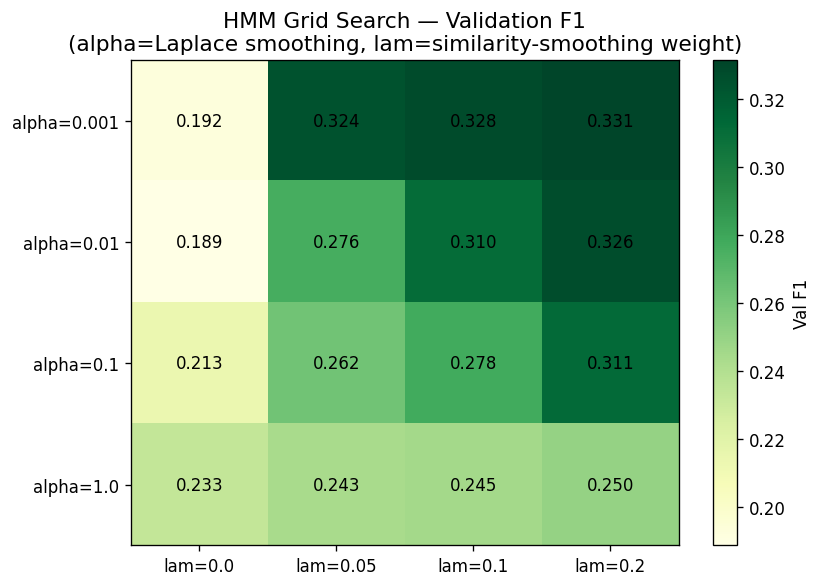

In [22]:
# Visualise grid-search heatmap
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='alpha', columns='lam', values='val_f1')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(lam_values)))
ax.set_yticks(range(len(alpha_values)))
ax.set_xticklabels([f'lam={v}' for v in lam_values])
ax.set_yticklabels([f'alpha={v}' for v in alpha_values])
for i in range(len(alpha_values)):
    for j in range(len(lam_values)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label="Val F1")
ax.set_title("HMM Grid Search — Validation F1\n(alpha=Laplace smoothing, lam=similarity-smoothing weight)")
plt.tight_layout()
plt.show()

### Final Model Training

In [23]:
hmm_final = HiddenMarkovModel(
    alpha = best['alpha'],
    lam = best['lam'],
    sim_index = sim_index,
)
hmm_final.fit(all_train_tokens, all_train_tags)

print(f"Final HMM trained on {len(all_train_tokens)} resumes")
print(f"alpha={best['alpha']}, lam={best['lam']}")
print(f"Tags   : {len(hmm_final.tags_)}")
print(f"Vocab  : {len(hmm_final.vocab_):,} tokens")

Final HMM trained on 333 resumes
alpha=0.001, lam=0.2
Tags   : 20
Vocab  : 7,157 tokens


### Probability Distribution Inspection

Trasition Matrix

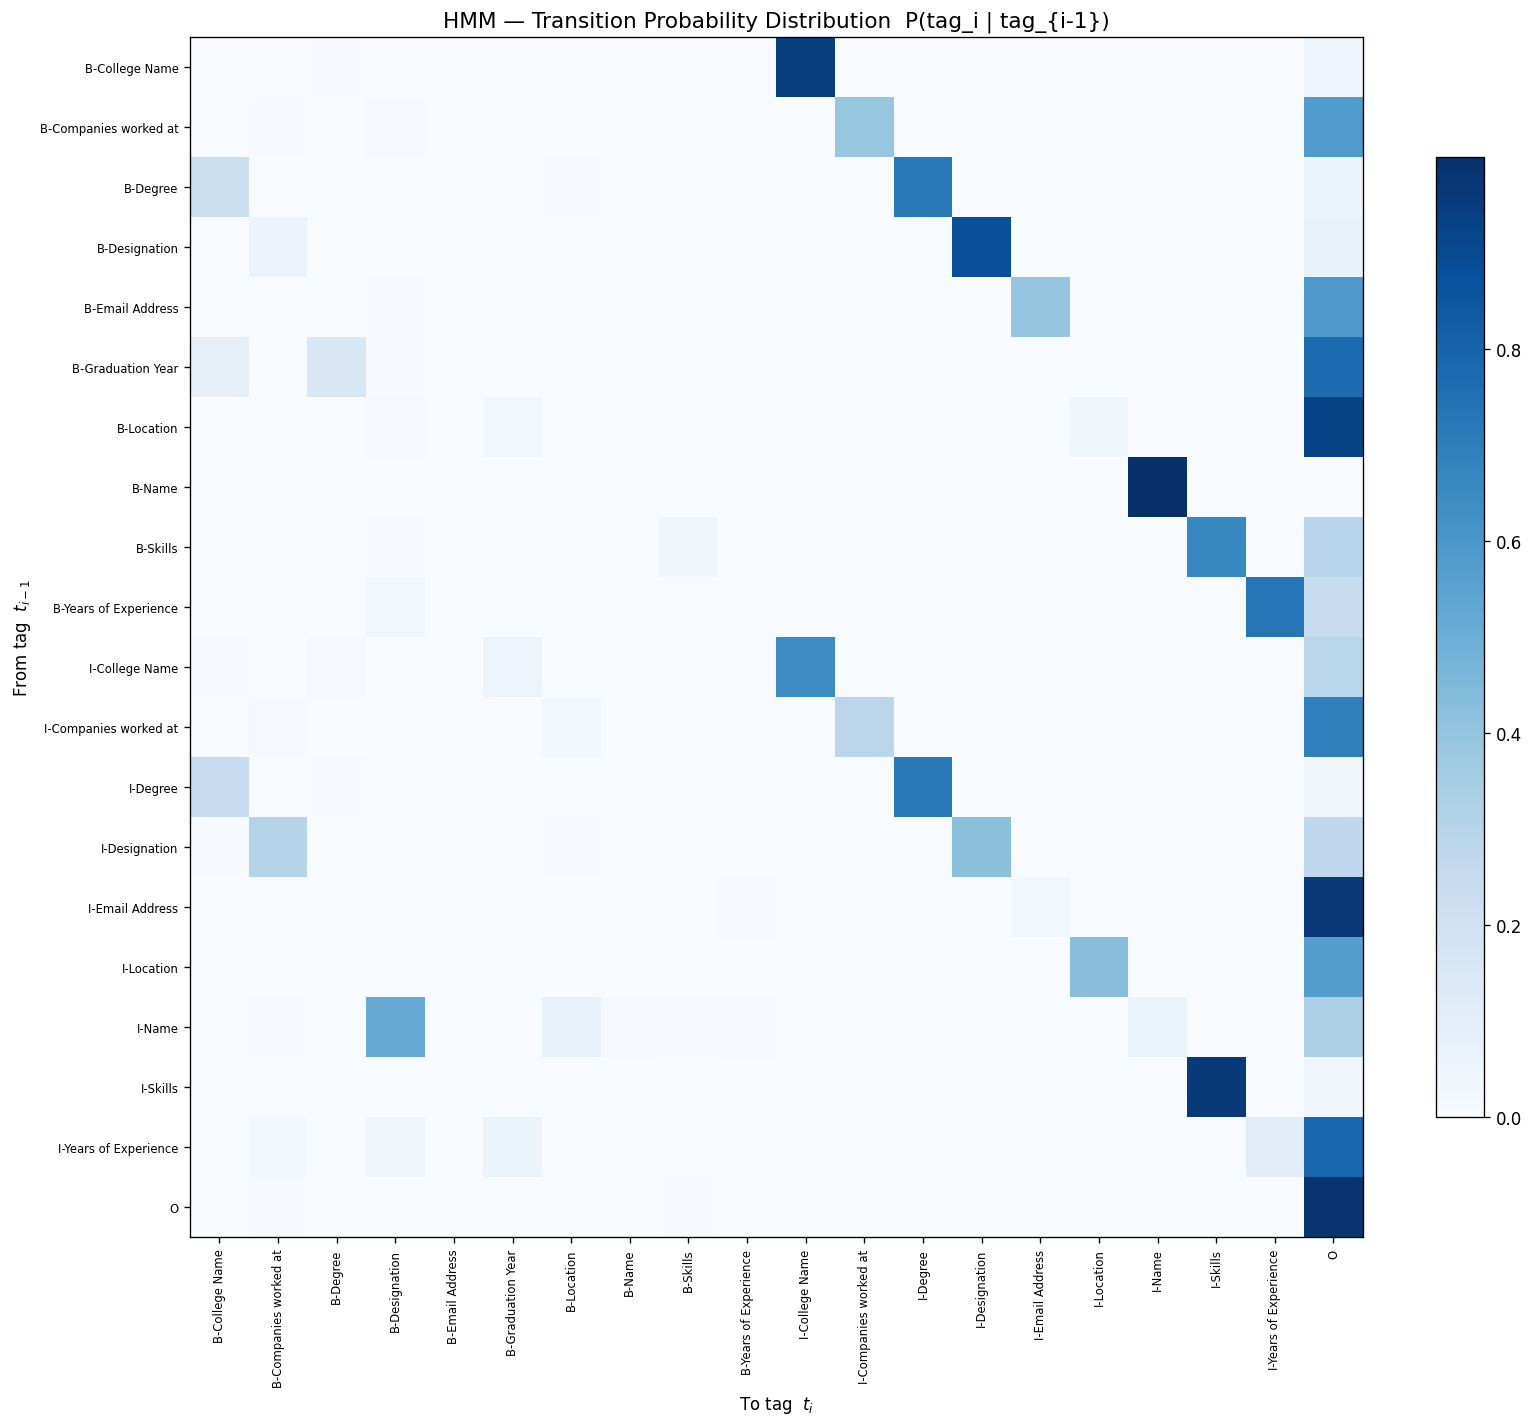

In [24]:
# Convert log-probs back to probabilities for display
trans_probs = np.exp(hmm_final.log_trans_)
tag_labels = hmm_final.tags_

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(trans_probs, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(tag_labels)))
ax.set_yticks(range(len(tag_labels)))
ax.set_xticklabels(tag_labels, rotation=90, fontsize=7)
ax.set_yticklabels(tag_labels, fontsize=7)
ax.set_xlabel("To tag  $t_i$")
ax.set_ylabel("From tag  $t_{i-1}$")
ax.set_title("HMM — Transition Probability Distribution  P(tag_i | tag_{i-1})")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Top Emission Probabilities per Tag

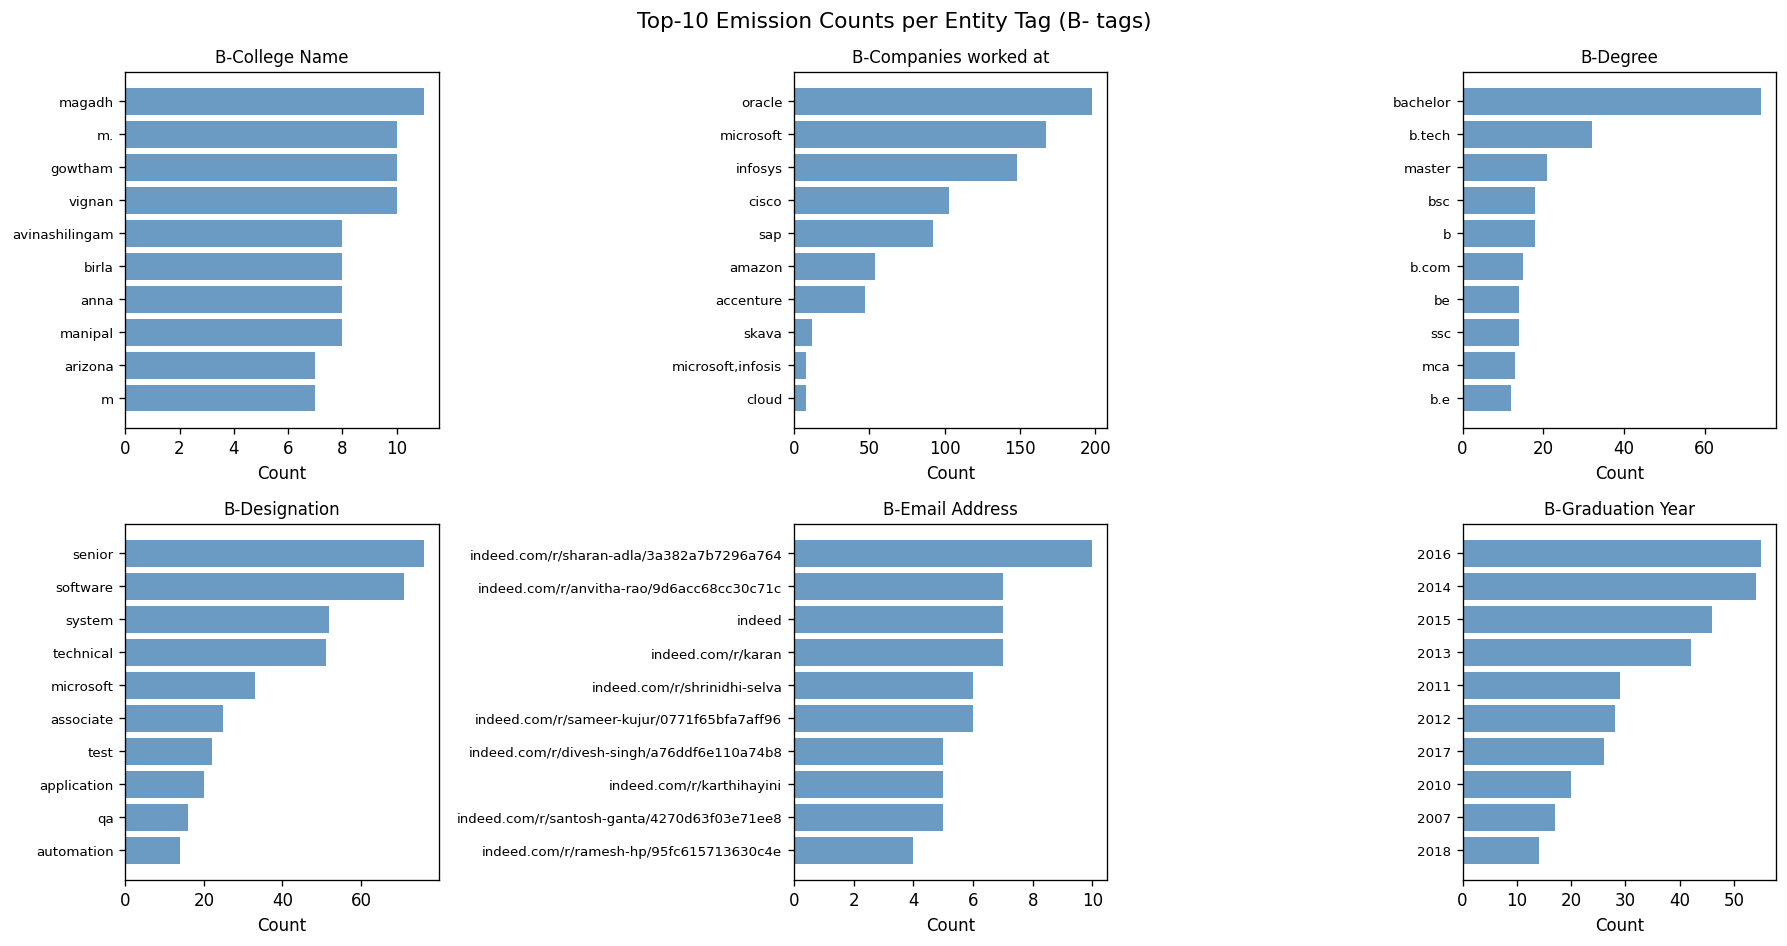

In [25]:
TOP_N   = 10
# Pick a few representative tags to display
display_tags = [
    t for t in hmm_final.tags_
    if t.startswith('B-') and hmm_final._tag_counts[t] > 5][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, tag in zip(axes, display_tags):
    emit_dict = hmm_final._emit_counts[tag]
    top = sorted(emit_dict.items(), key=lambda x: -x[1])[:TOP_N]
    words, counts = zip(*top) if top else ([], [])
    ax.barh(range(len(words)), counts, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"{tag}", fontsize=10)
    ax.set_xlabel("Count")

for ax in axes[len(display_tags):]:
    ax.axis('off')

fig.suptitle(f"Top-{TOP_N} Emission Counts per Entity Tag (B- tags)", fontsize=13)
plt.tight_layout()
plt.show()

## Evaluation

In [26]:
y_pred_test = hmm_final.predict(test_tokens)

print("=== Test Set Evaluation (seqeval — entity-level) ===")
print(classification_report(test_tags, y_pred_test, digits=4))

=== Test Set Evaluation (seqeval — entity-level) ===
                     precision    recall  f1-score   support

       College Name     0.1733    0.3714    0.2364        35
Companies worked at     0.2500    0.3857    0.3034        70
             Degree     0.3478    0.6667    0.4571        36
        Designation     0.2353    0.3784    0.2902        74
      Email Address     0.0000    0.0000    0.0000        26
    Graduation Year     0.4872    0.5135    0.5000        37
           Location     0.0086    0.0909    0.0157        11
               Name     0.9118    0.8857    0.8986        35
             Skills     0.0000    0.0000    0.0000        45
Years of Experience     0.0127    0.3333    0.0244         3

          micro avg     0.1923    0.3871    0.2569       372
          macro avg     0.2427    0.3626    0.2726       372
       weighted avg     0.2784    0.3871    0.3162       372



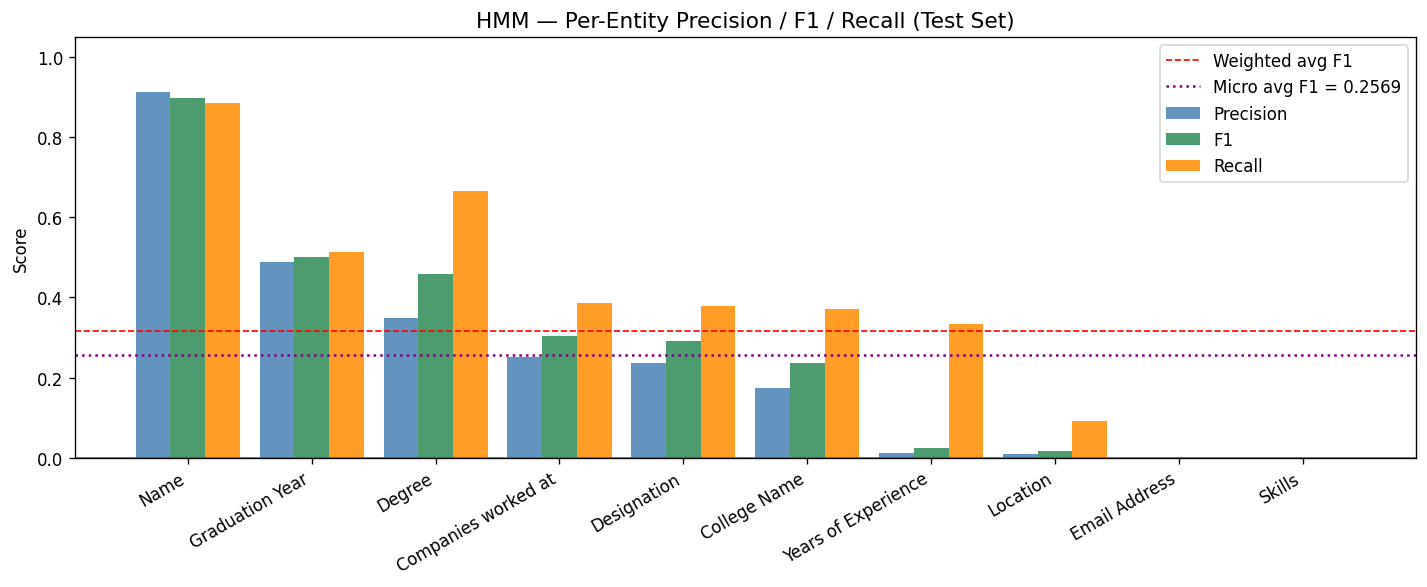

In [27]:
from seqeval.metrics import classification_report as seq_report

report_dict = seq_report(test_tags, y_pred_test, digits=4, output_dict=True)

micro_f1  = report_dict['micro avg']['f1-score']
macro_f1  = report_dict['macro avg']['f1-score']

per_label = {
    k: v for k, v in report_dict.items() if isinstance(v, dict) and k not in ('micro avg', 'macro avg', 'weighted avg')
}

labels_sorted = sorted(per_label, key=lambda k: per_label[k]['f1-score'], reverse=True)
f1_scores = [per_label[k]['f1-score'] for k in labels_sorted]
precisions = [per_label[k]['precision'] for k in labels_sorted]
recalls = [per_label[k]['recall'] for k in labels_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
x, w = range(len(labels_sorted)), 0.28
ax.bar([i - w for i in x], precisions, width=w, label='Precision', color='steelblue', alpha=0.85)
ax.bar(list(x), f1_scores, width=w, label='F1', color='seagreen',   alpha=0.85)
ax.bar([i + w for i in x], recalls,    width=w, label='Recall', color='darkorange', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("HMM — Per-Entity Precision / F1 / Recall (Test Set)")
ax.axhline(report_dict.get('weighted avg', {}).get('f1-score', 0), color='red', linestyle='--', linewidth=1, label='Weighted avg F1')
ax.axhline(micro_f1, color='purple', linestyle=':', linewidth=1.5, label=f'Micro avg F1 = {micro_f1:.4f}')
ax.axhline()
ax.legend()
plt.tight_layout()
plt.show()

### Inference Demo

In [28]:
import unicodedata as _ud

# Minimal normalization — must match Preprocessing.ipynb
_TECH = re.compile(r'[+#]|\d|\.\w|^[A-Z]{1,5}$|^\.[a-z]+')

def _norm(tok: str) -> str | None:
    is_tech = bool(_TECH.search(tok))
    t = _ud.normalize('NFKD', tok).encode('ascii', 'ignore').decode('ascii').lower()
    t = re.sub(r'^[^\w.#+]+|[^\w.#+]+$', '', t)
    if not t or re.match(r'^[^\w.#+]+$|^[\-\u2013\u2014]+$', t):
        return None
    return t


def predict_resume(text: str) -> list[tuple[str, str]]:
    """
    Run HMM inference on a raw resume text string.
    Returns list of (norm_token, predicted_label) pairs.
    """
    raw_tokens = [m.group() for m in re.finditer(r'\S+', text)]
    norm_tokens = [n for tok in raw_tokens for n in [_norm(tok)] if n]
    if not norm_tokens:
        return []
    pred_tags = hmm_final.predict_single(norm_tokens)
    return list(zip(norm_tokens, pred_tags))


def extract_entities(predictions: list[tuple[str, str]]) -> dict:
    """Group BIO-tagged tokens into entity strings by label."""
    entities: dict = {}
    current_toks, current_lbl = [], None
    for tok, tag in predictions:
        if tag.startswith('B-'):
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [tok], tag[2:]
        elif tag.startswith('I-') and current_toks:
            current_toks.append(tok)
        else:
            if current_toks:
                entities.setdefault(current_lbl, []).append(' '.join(current_toks))
            current_toks, current_lbl = [], None
    if current_toks:
        entities.setdefault(current_lbl, []).append(' '.join(current_toks))
    return entities


# Demo on first test resume
demo_idx   = idx_test[0]
demo_text  = ' '.join(
    tok for tok, _ in processed[demo_idx]['word_bio_raw']
)

predictions = predict_resume(demo_text)
entities = extract_entities(predictions)

print('=== Extracted Entities ===')
for label, vals in entities.items():
    print(f"{label:<30} {vals[:3]}")   # show first 3 examples per label

print()
print("=== Token-level predictions (first 30) ===")
print(f"{'-'*55}")
print(f"{'Token':<30} {'Predicted Tag'}")
print(f"{'-'*55}")
for tok, tag in predictions[:30]:
    print(f"{tok:<30} {tag}")

=== Extracted Entities ===
Name                           ['mohammed murtuza']
Designation                    ['escalation manager', 'escalation manager', 'global teams within']
Companies worked at            ['microsoft india', 'microsoft india', 'microsoft']
Location                       ['hyderabad', 'indeed indeed.com/r/mohammed murtuza/0cdc3284bf1bbeab', 'microsoft. primary duties include leading team operations managing team resources leading amp driving high impact technical incidents to resolution. providing executive updates']
Years of Experience            ['responsibilities working', "20 l1's", 'activities. validating']
College Name                   ['reoccurrence of incident.', 'pre communication preparations', 'areas of sap-srm.']
Degree                         ['problem.', 'following', "guided customer's in helping"]
Skills                         ['free/busy exchange activesync outlook web access outlook connectivity rpc over http outlook', 'skills active directory 2 y

### Save Model

In [29]:
# Save trained HMM model
model_save = Path('./model_result')
model_save.mkdir(exist_ok=True)

import copy
hmm_to_save = copy.copy(hmm_final)
hmm_to_save._trans_counts = {k: dict(v) for k, v in hmm_final._trans_counts.items()}
hmm_to_save._emit_counts = {k: dict(v) for k, v in hmm_final._emit_counts.items()}
hmm_to_save._tag_counts = dict(hmm_final._tag_counts)
hmm_to_save._init_counts = dict(hmm_final._init_counts)
hmm_to_save._trans_from_counts = dict(hmm_final._trans_from_counts)

with open(model_save / 'hmm_model.pkl', 'wb') as f:
    pickle.dump(hmm_to_save, f)

# Save test predictions for comparison across all models 
results = {
    'model'          : 'HMM',
    'best_alpha'     : best['alpha'],        
    'best_lam'       : best['lam'],
    'val_f1'         : best['val_f1'],
    'test_f1'        : f1_score(test_tags, y_pred_test),
    'test_f1_micro'  : report_dict['micro avg']['f1-score'],
    'test_f1_macro'  : report_dict['macro avg']['f1-score'],
    'test_precision' : precision_score(test_tags, y_pred_test),
    'test_recall'    : recall_score(test_tags, y_pred_test),
    'y_test'         : test_tags,
    'y_pred'         : y_pred_test,
    'idx_test'       : idx_test,
}

with open(model_save / 'results_hmm.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Model saved  -> model_result/hmm_model.pkl")
print("Results saved -> model_result/results_hmm.pkl")
print()
print("=== Final HMM Scores ===")
print(f"Val  F1       : {best['val_f1']:.4f}")
print(f"Test F1       : {results['test_f1']:.4f}")
print(f"Test Micro F1 : {results['test_f1_micro']:.4f}")
print(f"Test Macro F1 : {results['test_f1_macro']:.4f}")
print(f"Test Precision: {results['test_precision']:.4f}")
print(f"Test Recall   : {results['test_recall']:.4f}")

Model saved  -> model_result/hmm_model.pkl
Results saved -> model_result/results_hmm.pkl

=== Final HMM Scores ===
Val  F1       : 0.3313
Test F1       : 0.2569
Test Micro F1 : 0.2569
Test Macro F1 : 0.2726
Test Precision: 0.1923
Test Recall   : 0.3871
